# Final-round experiment: nlp_id preprocessing, InSet lexicon counts and fastText embeddings for the first 1,000 labelled reviews

## Helper

In [ ]:
FASTTEXT_MODEL_PATH = "cc.id.300.bin"

In [49]:
def tsne_plot(for_word, w2v_model):
    # trained fastText model dimention
    dim_size = w2v_model.wv.vectors.shape[1]

    arrays = np.empty((0, dim_size), dtype='f')
    word_labels = [for_word]
    color_list = ['red']

    # adds the vector of the query word
    arrays = np.append(arrays, w2v_model.wv.__getitem__([for_word]), axis=0)

    # gets list of most similar words
    sim_words = w2v_model.wv.most_similar(for_word, topn=10)

    # adds the vector for each of the closest words to the array
    for wrd_score in sim_words:
        wrd_vector = w2v_model.wv.__getitem__([wrd_score[0]])
        word_labels.append(wrd_score[0])
        color_list.append('green')
        arrays = np.append(arrays, wrd_vector, axis=0)

    #---------------------- Apply PCA and tsne to reduce dimention --------------

    # fit 2d PCA model to the similar word vectors
    model_pca = PCA(n_components=10).fit_transform(arrays)

    # Finds 2d coordinates t-SNE
    np.set_printoptions(suppress=True)
    Y = TSNE(n_components=2, random_state=0, perplexity=10).fit_transform(model_pca)

    # Sets everything up to plot
    df_plot = pd.DataFrame({'x': [x for x in Y[:, 0]],
                            'y': [y for y in Y[:, 1]],
                            'words_name': word_labels,
                            'words_color': color_list})

    #------------------------- tsne plot Python -----------------------------------

    # plot dots with color and position
    plot_dot = sns.regplot(data=df_plot,
                           x="x",
                           y="y",
                           fit_reg=False,
                           marker="o",
                           scatter_kws={'s': 40,
                                        'facecolors': df_plot['words_color']
                                        }
                           )

    # Adds annotations with color one by one with a loop
    for line in range(0, df_plot.shape[0]):
        plot_dot.text(df_plot["x"][line],
                      df_plot['y'][line],
                      '  ' + df_plot["words_name"][line].title(),
                      horizontalalignment='left',
                      verticalalignment='bottom', size='medium',
                      color=df_plot['words_color'][line],
                      weight='normal'
                      ).set_size(15)

    plt.xlim(Y[:, 0].min() - 50, Y[:, 0].max() + 50)
    plt.ylim(Y[:, 1].min() - 50, Y[:, 1].max() + 50)

    plt.title('t-SNE visualization for word "{}'.format(for_word.title()) + '"')


## Load Data

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split

from gensim.models.fasttext import load_facebook_model
import tensorflow as tf

from sklearn.model_selection import train_test_split, cross_val_score, RepeatedStratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, recall_score, precision_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [4]:
jne = pd.read_csv("scrape_dataset/raw/ReviewJNEIndonesia.csv")
jnt = pd.read_csv("scrape_dataset/raw/ReviewJ&TIndonesia.csv")
jne["expedition"] = "JNE"
jnt["expedition"] = "J&T"
df = pd.concat([jne, jnt])
df.drop(["Unnamed: 0"], axis=1, inplace=True)

print("JNE shape:", jne.shape, "J&T shape:", jnt.shape, "Combined shape:", df.shape)
print(df.columns)
df.head()

JNE shape: (61529, 15) J&T shape: (69936, 15) Combined shape: (131465, 14)
Index(['source', 'review_id', 'user_name', 'review_title',
       'review_description', 'rating', 'thumbs_up', 'review_date',
       'developer_response', 'developer_response_date', 'appVersion',
       'laguage_code', 'country_code', 'expedition'],
      dtype='object')


,source,review_id,user_name,review_title,review_description,rating,thumbs_up,review_date,developer_response,developer_response_date,appVersion,laguage_code,country_code,expedition
0,Google Play,3899fc94-7b59-45ba-ab06-6ad26ffb71d1,Ahmad Firdaus,NaN,Untuk pengiriman ke pandeglang sangat lambat. ...,3,0,2023-10-03 07:57:08,NaN,NaN,NaN,id,id,JNE
1,Google Play,afee4dfd-d2d1-4e5f-a9d8-f9f1f0e1ac01,marifat dieyah,NaN,buruk sekali pengiriman JNE ini . lemot pol .,1,0,2023-10-03 07:17:46,NaN,NaN,NaN,id,id,JNE
2,Google Play,8f2ab06b-4f0d-4a82-a6c2-4dba644472ef,nur sela,NaN,paket muter muter dan gak jalan jalan cs bilan...,1,0,2023-10-03 06:14:08,NaN,NaN,NaN,id,id,JNE
3,Google Play,6dc71aee-60c3-4955-8f7a-9e96962bda12,robby sobara,NaN,"Expedisi paling buruk, pengiriman dari indrama...",1,0,2023-10-03 05:15:55,NaN,NaN,1.2.6,id,id,JNE
4,Google Play,26fdb423-103f-41b1-bd8e-825ea3e8ddf0,William Aditya,NaN,Nobody at office. Chat cs jne infonya kantor t...,1,0,2023-10-03 04:42:36,NaN,NaN,2.3.9,id,id,JNE


In [23]:
rating_5_and_1_df = df[(df["rating"] == 5) | (df["rating"] == 1)]
print("Rating 5 and 1 shape:", rating_5_and_1_df.shape)
rating_5_and_1_df.head()

Rating 5 and 1 shape: (110177, 14)


,source,review_id,user_name,review_title,review_description,rating,thumbs_up,review_date,developer_response,developer_response_date,appVersion,laguage_code,country_code,expedition
1,Google Play,afee4dfd-d2d1-4e5f-a9d8-f9f1f0e1ac01,marifat dieyah,NaN,buruk sekali pengiriman JNE ini . lemot pol .,1,0,2023-10-03 07:17:46,NaN,NaN,NaN,id,id,JNE
2,Google Play,8f2ab06b-4f0d-4a82-a6c2-4dba644472ef,nur sela,NaN,paket muter muter dan gak jalan jalan cs bilan...,1,0,2023-10-03 06:14:08,NaN,NaN,NaN,id,id,JNE
3,Google Play,6dc71aee-60c3-4955-8f7a-9e96962bda12,robby sobara,NaN,"Expedisi paling buruk, pengiriman dari indrama...",1,0,2023-10-03 05:15:55,NaN,NaN,1.2.6,id,id,JNE
4,Google Play,26fdb423-103f-41b1-bd8e-825ea3e8ddf0,William Aditya,NaN,Nobody at office. Chat cs jne infonya kantor t...,1,0,2023-10-03 04:42:36,NaN,NaN,2.3.9,id,id,JNE
5,Google Play,a27a2155-92dd-46a4-97a8-b2df337d7d00,Toni Wijaya,NaN,App payah mau cek resi aja gagal Padahal tingg...,1,0,2023-10-03 04:36:01,NaN,NaN,1.2.6,id,id,JNE


In [24]:
train_df = rating_5_and_1_df[rating_5_and_1_df["rating"] == 5].sample(500, random_state=42)
train_df = pd.concat([train_df, rating_5_and_1_df[rating_5_and_1_df["rating"] == 1].sample(500, random_state=42)])
test_df = rating_5_and_1_df.drop(train_df.index)

print("Train shape:", train_df.shape, "Test shape:", test_df.shape)

Train shape: (1000, 14) Test shape: (108395, 14)


In [25]:
train_df.to_csv("scrape_dataset/train_iter1.csv", index=False)
test_df.to_csv("scrape_dataset/test_iter1.csv", index=False)

In [26]:
test_df.rating.value_counts()

1    77568
5    30827
Name: rating, dtype: int64

In [27]:
train_df.rating.value_counts()

5    500
1    500
Name: rating, dtype: int64

## Text Preprocessing

In [35]:
from nlp_id.stopword import StopWord
from nlp_id.lemmatizer import Lemmatizer
from nlp_id.tokenizer import Tokenizer
from nlp_id.postag import PosTag

In [36]:
stopwords = StopWord().get_stopword()
lemmatizer = Lemmatizer()
tokenizer = Tokenizer()
postagger = PosTag()

d:\miniconda3\envs\tf\lib\site-packages\sklearn\base.py:318: UserWarning: Trying to unpickle estimator DictVectorizer from version 0.22 when using version 1.2.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
d:\miniconda3\envs\tf\lib\site-packages\sklearn\base.py:318: UserWarning: Trying to unpickle estimator DecisionTreeClassifier from version 0.22 when using version 1.2.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
d:\miniconda3\envs\tf\lib\site-packages\sklearn\base.py:318: UserWarning: Trying to unpickle estimator RandomForestClassifier from version 0.22 when using version 1.2.2. This might lead to breaking code or invalid results. Use at your own

In [30]:
def tokenize_lemmatize(text):
    lemmatized_doc = lemmatizer.lemmatize(text)
    return [word for word in tokenizer.tokenize(lemmatized_doc) if word not in stopwords]

In [31]:
train_df["review_tokenized"] = train_df["review_description"].apply(tokenize_lemmatize)
test_df["review_tokenized"] = test_df["review_description"].apply(tokenize_lemmatize)
train_df.head()

,source,review_id,user_name,review_title,review_description,rating,thumbs_up,review_date,developer_response,developer_response_date,appVersion,laguage_code,country_code,expedition,review_tokenized
28985,Google Play,2c6973de-c75a-405d-9b9e-e5bf233f200a,Bayu Winalas,NaN,Hingga ini masih baik-baik aja 🥰🥰🥰,5,0,2021-09-02 03:36:26,NaN,NaN,3.13.1,id,id,J&T,[hingga]
14436,Google Play,94fde3c7-4a37-4c92-875c-2f33d585f490,Wahyono 345,NaN,"Terima kasih JNE,selama ini selalu pakai jasa ...",5,1,2020-12-14 14:38:40,NaN,NaN,1.1.14,id,id,JNE,"[terima, kasih, jne, pakai, jasa, jne, lancar,..."
57393,Google Play,31927262-6bd2-4ec5-abe5-757dc7df9a7e,Pengguna Google,NaN,ok lah bisa ngebantu,5,0,2019-03-12 15:29:01,NaN,NaN,3.1.1,id,id,J&T,"[ok, ngebantu]"
57875,Google Play,9f71ba44-d15c-438b-b3d0-22f861137f03,Pengguna Google,NaN,langganan,5,0,2019-02-28 00:50:52,NaN,NaN,3.1.1,id,id,J&T,[langgan]
69576,Google Play,b409cdd4-1998-4d48-a486-8a5846e446f4,Pengguna Google,NaN,T O P BGT . . Pengiriman super cepat bgt. .suk...,5,0,2016-05-04 12:17:49,NaN,NaN,NaN,id,id,J&T,"[t, o, p, bgt, kirim, super, cepat, bgt, suka,..."


In [41]:
 # kita muat kata-kata bersentiment tersebut ke memori
# dalam bentuk python's dictionary
# key = word
# value = sentiment score

def load_sentword(filename):
    file = open(filename, "r")
    file.readline()  # skip header
    sentword_score = {}
    for line in file:
        word, score = line.strip().split("\t")
        score = int(score)
        sentword_score[word] = score
    file.close()
    return sentword_score


sentword_score_neg = load_sentword("dataset/negative.tsv")
sentword_score_pos = load_sentword("dataset/positive.tsv")


# num positives or negatives
def num(text, sentword_score):
    count = 0
    for word in text:
        if word in sentword_score:
            count += 1
    return count


# num JJ positives or negatives
def num_jj(text, sentword_score):
    count = 0
    for word, pos in postagger.get_pos_tag(" ".join(text)):
        if pos == "JJ":
            if word in sentword_score:
                count += 1
    return count

def apply_sentword(df):
    df = df.copy()
    df["num_pos_review"] = df.review_tokenized. \
        map(lambda x: num(x, sentword_score_pos))

    df["num_neg_review"] = df.review_tokenized. \
        map(lambda x: num(x, sentword_score_neg))

    df["num_jj_pos_review"] = df.review_tokenized. \
        map(lambda x: num_jj(x, sentword_score_pos))

    df["num_jj_neg_review"] = df.review_tokenized. \
        map(lambda x: num_jj(x, sentword_score_neg))
    return df

# print(sentword_score)
print(sentword_score_neg['mencederai'])
print(sentword_score_pos['bagus'])

-4
2


In [42]:
train_df = apply_sentword(train_df)
test_df = apply_sentword(test_df)
train_df.head()

,source,review_id,user_name,review_title,review_description,rating,thumbs_up,review_date,developer_response,developer_response_date,appVersion,laguage_code,country_code,expedition,review_tokenized,num_pos_review,num_neg_review,num_jj_pos_review,num_jj_neg_review
28985,Google Play,2c6973de-c75a-405d-9b9e-e5bf233f200a,Bayu Winalas,NaN,Hingga ini masih baik-baik aja 🥰🥰🥰,5,0,2021-09-02 03:36:26,NaN,NaN,3.13.1,id,id,J&T,[hingga],0,0,0,0
14436,Google Play,94fde3c7-4a37-4c92-875c-2f33d585f490,Wahyono 345,NaN,"Terima kasih JNE,selama ini selalu pakai jasa ...",5,1,2020-12-14 14:38:40,NaN,NaN,1.1.14,id,id,JNE,"[terima, kasih, jne, pakai, jasa, jne, lancar,...",6,2,1,1
57393,Google Play,31927262-6bd2-4ec5-abe5-757dc7df9a7e,Pengguna Google,NaN,ok lah bisa ngebantu,5,0,2019-03-12 15:29:01,NaN,NaN,3.1.1,id,id,J&T,"[ok, ngebantu]",1,0,0,0
57875,Google Play,9f71ba44-d15c-438b-b3d0-22f861137f03,Pengguna Google,NaN,langganan,5,0,2019-02-28 00:50:52,NaN,NaN,3.1.1,id,id,J&T,[langgan],1,0,0,0
69576,Google Play,b409cdd4-1998-4d48-a486-8a5846e446f4,Pengguna Google,NaN,T O P BGT . . Pengiriman super cepat bgt. .suk...,5,0,2016-05-04 12:17:49,NaN,NaN,NaN,id,id,J&T,"[t, o, p, bgt, kirim, super, cepat, bgt, suka,...",6,5,2,2


In [45]:
train_df.to_csv("scrape_dataset/train_iter1_tokenized.csv", index=False)
test_df.to_csv("scrape_dataset/test_iter1_tokenized.csv", index=False)

In [44]:
ft_model = load_facebook_model(FASTTEXT_MODEL_PATH)

In [46]:
ft_model.wv.most_similar('telat', topn=10)

[('terlambat', 0.7887392640113831),
 ('telatnya', 0.7414048314094543),
 ('telat-telat', 0.7296267151832581),
 ('telat.', 0.6633073687553406),
 ('setelat', 0.641062319278717),
 ('Telat', 0.640042781829834),
 ('terlambatnya', 0.628247082233429),
 ('setelat-telatnya', 0.603618860244751),
 ('keterlambatan', 0.6011660099029541),
 ('keterlambatannya', 0.5839794874191284)]

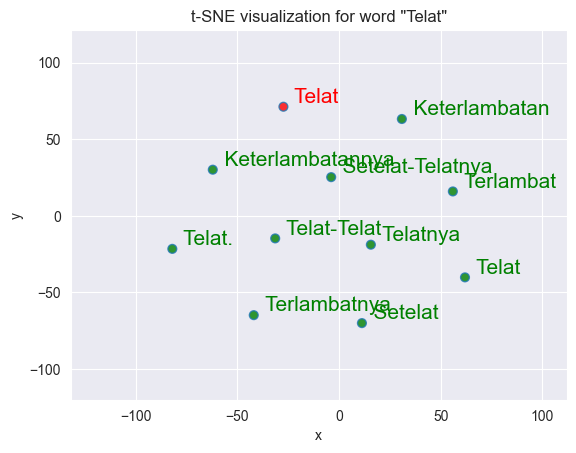

In [50]:
tsne_plot(for_word='telat', w2v_model=ft_model)

In [51]:
ft_model.wv.most_similar('cepet', topn=10)

[('cepet.', 0.8128264546394348),
 ('cepet-cepet', 0.7817241549491882),
 ('cepet2', 0.7654396295547485),
 ('cepetnya', 0.7385133504867554),
 ('cepet2an', 0.7382088303565979),
 ('cepetan', 0.727185070514679),
 ('cepat', 0.6841765642166138),
 ('secepet', 0.6754299402236938),
 ('cepet-cepetan', 0.6712823510169983),
 ('kecepetan', 0.6614734530448914)]

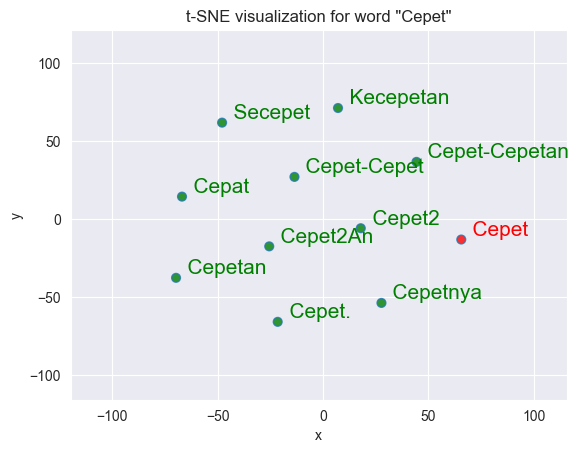

In [52]:
tsne_plot(for_word='cepet', w2v_model=ft_model)

In [59]:
train_embedded_words = [[ft_model.wv[word] for word in token] for token in tqdm(train_df['review_description'].tolist())]
train_embedded_words_encoding = [np.mean(embedded_word, axis=0) for embedded_word in tqdm(train_embedded_words)]
train_df_embedding = pd.DataFrame(train_embedded_words_encoding)

test_embedded_words = [[ft_model.wv[word] for word in token] for token in tqdm(test_df['review_description'].tolist())]
test_embedded_words_encoding = [np.mean(embedded_word, axis=0) for embedded_word in tqdm(test_embedded_words)]
test_df_embedding = pd.DataFrame(test_embedded_words_encoding)

train_df_embedding.head()

100%|██████████| 108395/108395 [00:05<00:00, 18163.76it/s]


,0,1,2,3,4,5,6,7,8,9,...,290,291,292,293,294,295,296,297,298,299
0,0.068198,0.161314,0.100605,-0.087958,-0.235161,0.193419,-0.005349,0.011546,-0.013537,0.004921,...,-0.114641,-0.024372,-0.084730,0.030176,-0.085399,0.209042,0.102710,0.147170,0.006335,-0.114017
1,0.079532,0.121288,0.123372,-0.119774,-0.230468,0.239383,0.018012,0.013864,0.059414,-0.003600,...,-0.110284,-0.034127,-0.123957,0.037025,-0.093741,0.234416,0.115612,0.210439,-0.024971,-0.186784
2,0.095103,0.159882,0.112222,-0.123081,-0.227587,0.255501,0.056669,0.053446,0.065029,-0.022800,...,-0.141132,-0.034091,-0.111670,0.030211,-0.093215,0.237475,0.121363,0.180906,0.006349,-0.154418
3,0.118797,0.163781,0.088775,-0.098342,-0.274476,0.292737,0.011129,0.129539,0.155184,-0.017317,...,-0.173486,-0.077080,-0.099721,0.067362,-0.086588,0.367617,0.124243,0.179280,0.027425,-0.177568
4,0.075459,0.087004,0.060561,-0.102081,-0.139302,0.174555,0.031671,-0.007101,0.029032,0.004245,...,-0.059167,0.003135,-0.092283,0.015003,-0.084312,0.183495,0.088491,0.174258,-0.018017,-0.133278


In [62]:
train_df_used = train_df[['num_pos_review', 'num_neg_review', 'num_jj_pos_review', 'num_jj_neg_review']]
train_df_merge = pd.concat([train_df_used.reset_index(drop=True), train_df_embedding], axis=1)
train_df_merge.head()

,num_pos_review,num_neg_review,num_jj_pos_review,num_jj_neg_review,0,1,2,3,4,5,...,290,291,292,293,294,295,296,297,298,299
0,0,0,0,0,0.068198,0.161314,0.100605,-0.087958,-0.235161,0.193419,...,-0.114641,-0.024372,-0.084730,0.030176,-0.085399,0.209042,0.102710,0.147170,0.006335,-0.114017
1,6,2,1,1,0.079532,0.121288,0.123372,-0.119774,-0.230468,0.239383,...,-0.110284,-0.034127,-0.123957,0.037025,-0.093741,0.234416,0.115612,0.210439,-0.024971,-0.186784
2,1,0,0,0,0.095103,0.159882,0.112222,-0.123081,-0.227587,0.255501,...,-0.141132,-0.034091,-0.111670,0.030211,-0.093215,0.237475,0.121363,0.180906,0.006349,-0.154418
3,1,0,0,0,0.118797,0.163781,0.088775,-0.098342,-0.274476,0.292737,...,-0.173486,-0.077080,-0.099721,0.067362,-0.086588,0.367617,0.124243,0.179280,0.027425,-0.177568
4,6,5,2,2,0.075459,0.087004,0.060561,-0.102081,-0.139302,0.174555,...,-0.059167,0.003135,-0.092283,0.015003,-0.084312,0.183495,0.088491,0.174258,-0.018017,-0.133278


In [63]:
test_df_used = test_df[['num_pos_review', 'num_neg_review', 'num_jj_pos_review', 'num_jj_neg_review']]
test_df_merge = pd.concat([test_df_used.reset_index(drop=True), test_df_embedding], axis=1)
test_df_merge.head()

,num_pos_review,num_neg_review,num_jj_pos_review,num_jj_neg_review,0,1,2,3,4,5,...,290,291,292,293,294,295,296,297,298,299
0,1,3,0,1,0.096491,0.121243,0.106782,-0.102587,-0.185303,0.234153,...,-0.127207,-0.048857,-0.111426,0.009179,-0.093515,0.204034,0.122025,0.203768,-0.022865,-0.141156
1,8,1,0,0,0.092281,0.141640,0.115846,-0.113823,-0.234163,0.249931,...,-0.118303,-0.032440,-0.112604,0.044147,-0.079052,0.237601,0.127538,0.161902,-0.005421,-0.168517
2,7,6,0,1,0.086769,0.148600,0.113243,-0.123437,-0.221377,0.265899,...,-0.132671,-0.028787,-0.133232,0.028386,-0.091276,0.228775,0.117080,0.178259,-0.021349,-0.151501
3,1,2,0,0,0.079540,0.128231,0.116235,-0.137986,-0.212968,0.244295,...,-0.099755,-0.026252,-0.104809,0.046918,-0.079272,0.229682,0.113742,0.190178,-0.026204,-0.167528
4,1,2,0,0,0.087812,0.148139,0.124524,-0.111222,-0.236293,0.264034,...,-0.131644,-0.032578,-0.131859,0.030560,-0.082264,0.212377,0.120714,0.173190,-0.012559,-0.166908
